## IMPORTING AND LOADING DATA

In [121]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [78]:
## Key checks
print(df.info()) # basic info


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB
None


In [81]:

# TARGET VARIABLE DISTRIBUTION

print(f"Dataset Shape: {df.shape}")
# Checking how many customers stayed vs churned

churn_counts = df['churn'].value_counts()

print("Customer Churn Distribution:")
print(churn_counts)

# Calculating churn percentage
churn_rate = df['churn'].mean() * 100

print(f"\nOverall churn rate: {churn_rate:.2f}%")

Dataset Shape: (10000, 11)
Customer Churn Distribution:
churn
0    7963
1    2037
Name: count, dtype: int64

Overall churn rate: 20.37%


## EXPLORATORY DATA ANALYSIS
#### Understand customer behavior patterns and identify factors associated with customer churn.

In [13]:
# Statistical summary
print(df.describe())

       credit_score           age        tenure        balance  \
count  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288   
std       96.653299     10.487806      2.892174   62397.405202   
min      350.000000     18.000000      0.000000       0.000000   
25%      584.000000     32.000000      3.000000       0.000000   
50%      652.000000     37.000000      5.000000   97198.540000   
75%      718.000000     44.000000      7.000000  127644.240000   
max      850.000000     92.000000     10.000000  250898.090000   

       products_number  credit_card  active_member  estimated_salary  \
count     10000.000000  10000.00000   10000.000000      10000.000000   
mean          1.530200      0.70550       0.515100     100090.239881   
std           0.581654      0.45584       0.499797      57510.492818   
min           1.000000      0.00000       0.000000         11.580000   
25%           1.000000      0.00000       0.0

**TARGET OVERVIEW (CHURN SNAPSHOT)**

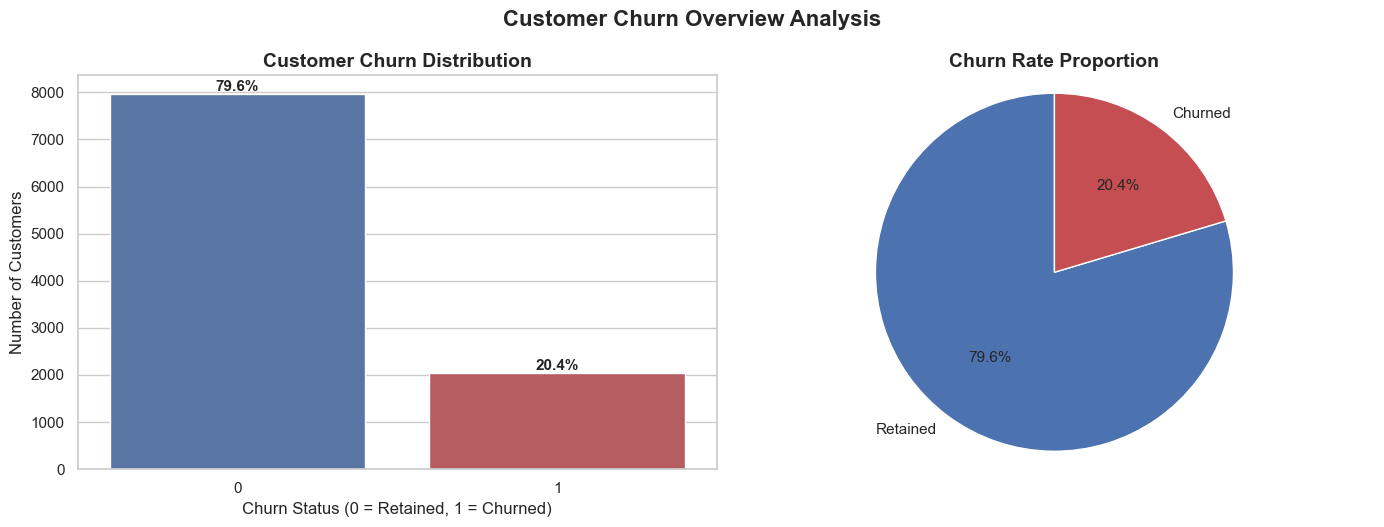

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))


#  CHURN COUNT DISTRIBUTION (WITH PERCENTAGES)

sns.countplot(
    x='churn',
    data=df,
    palette=['#4C72B0', '#C44E52'],
    ax=ax[0]
)

ax[0].set_title("Customer Churn Distribution", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Churn Status (0 = Retained, 1 = Churned)")
ax[0].set_ylabel("Number of Customers")


total = len(df)

for p in ax[0].patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax[0].annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
# CHURN PROPORTION (PIE CHART)

churn_labels = ['Retained', 'Churned']
churn_values = df['churn'].value_counts().sort_index()

ax[1].pie(
    churn_values,
    labels=churn_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#C44E52'],
    textprops={'fontsize': 11}
)
ax[1].set_title("Churn Rate Proportion", fontsize=14, fontweight='bold')
ax[1].axis('equal') 

# FINAL LAYOUT
plt.tight_layout()
plt.suptitle("Customer Churn Overview Analysis", fontsize=16, fontweight='bold', y=1.05)
plt.show()

**DEMOGRAPHIC IMPACT (WHO IS CHURNING?)**

Detected geography column: country


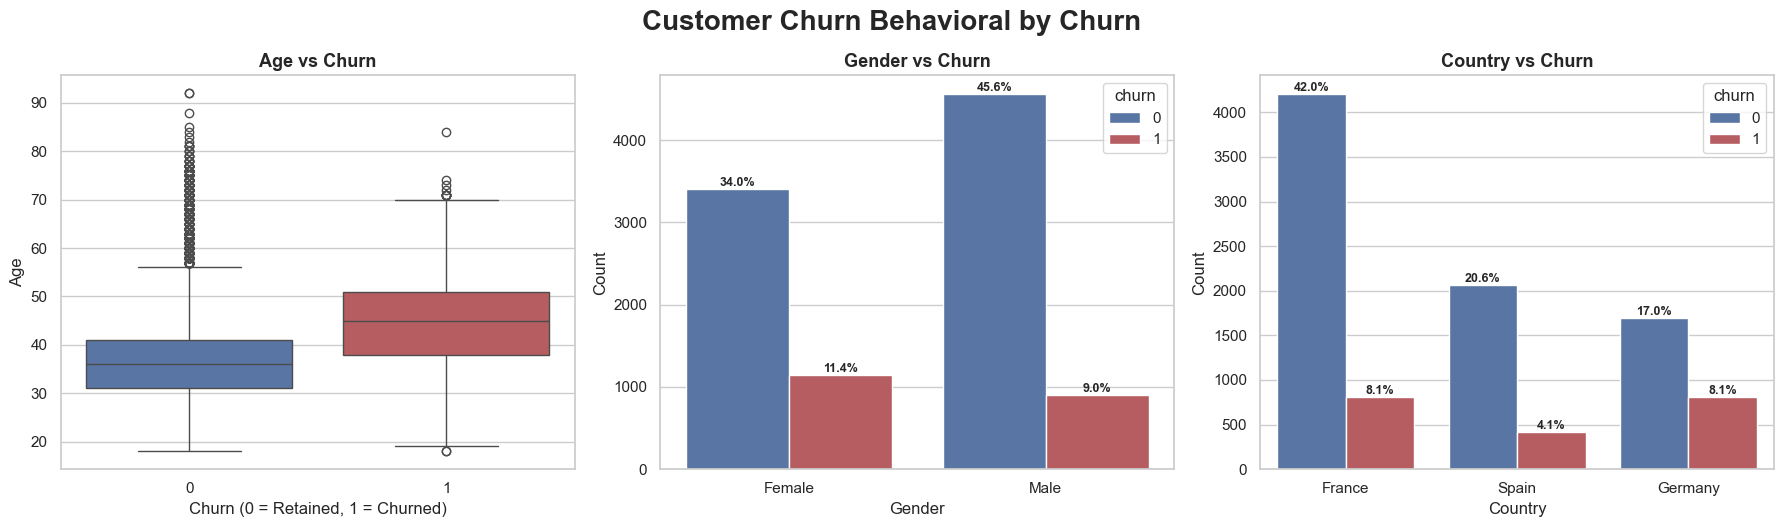

In [ ]:
sns.set_theme(style="whitegrid")
df.columns = df.columns.str.strip().str.lower()


geo_col = None
possible_geo_cols = ['geography', 'country', 'region', 'location']
for col in df.columns:
    if col in possible_geo_cols:
        geo_col = col
        break

print("Detected geography column:", geo_col)

fig, ax = plt.subplots(1, 3, figsize=(18,5))


# AGE vs CHURN

sns.boxplot(
    x='churn',
    y='age',
    data=df,
    palette=['#4C72B0', '#C44E52'],
    ax=ax[0]
)
ax[0].set_title("Age vs Churn", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Churn (0 = Retained, 1 = Churned)")
ax[0].set_ylabel("Age")

# PERCENTAGES

def add_percentage_labels(ax, df):
    total = len(df)

    for p in ax.patches:
        height = p.get_height()

        if height > 0:
            ax.annotate(
                f"{(height/total)*100:.1f}%",
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

# GENDER vs CHURN

sns.countplot(
    x='gender',
    hue='churn',
    data=df,
    palette=['#4C72B0', '#C44E52'],
    ax=ax[1]
)

ax[1].set_title("Gender vs Churn", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Count")

add_percentage_labels(ax[1], df)


#  GEOGRAPHY vs CHURN (SAFE VERSION)

if geo_col is not None:

    sns.countplot(
        x=geo_col,
        hue='churn',
        data=df,
        palette=['#4C72B0', '#C44E52'],
        ax=ax[2]
    )

    ax[2].set_title(f"{geo_col.capitalize()} vs Churn", fontsize=13, fontweight='bold')
    ax[2].set_xlabel(geo_col.capitalize())
    ax[2].set_ylabel("Count")

    add_percentage_labels(ax[2], df)

else:
    ax[2].text(
        0.5, 0.5,
        "No Geography/Country column found",
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    ax[2].set_axis_off()


plt.tight_layout()
plt.suptitle("Customer Churn Behavioral Analysis", fontsize=20, fontweight='bold', y=1.05)
plt.show()

- Customers above 40 show a higher likelihood of churn, peaking within the 45–55 age group. Gender differences in churn patterns are negligible.

- Germany records significantly higher churn rates at approximately 32%, while France and Spain maintain more stable customer bases at around 16–17%. This indicates a need for market-specific retention strategies.

**CUSTOMER ENGAGEMENT (MOST IMPORTANT GROUP)**

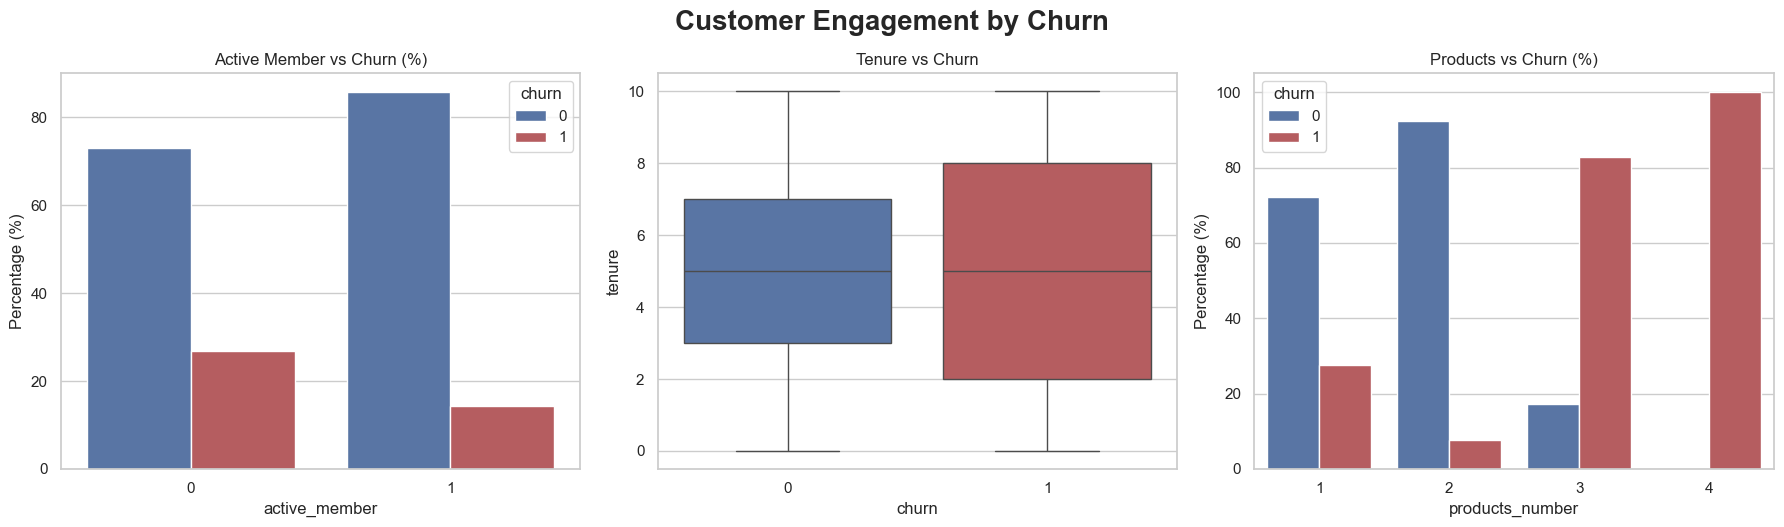

In [107]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))


#  Active Member (%)
active_table = (
    df.groupby(['active_member', 'churn'])
      .size()
      .reset_index(name='count')
)

active_table['percent'] = active_table.groupby('active_member')['count'].transform(
    lambda x: (x / x.sum()) * 100
)

sns.barplot(x='active_member', y='percent', hue='churn',
            data=active_table,
            palette=['#4C72B0', '#C44E52'],
            ax=ax[0])

ax[0].set_title("Active Member vs Churn (%)")
ax[0].set_ylabel("Percentage (%)")


# Tenure (unchanged)

sns.boxplot(x='churn', y='tenure', data=df,
            palette=['#4C72B0', '#C44E52'], ax=ax[1])

ax[1].set_title("Tenure vs Churn")

# Products (%)

products_table = (
    df.groupby(['products_number', 'churn'])
      .size()
      .reset_index(name='count')
)

products_table['percent'] = products_table.groupby('products_number')['count'].transform(
    lambda x: (x / x.sum()) * 100
)

sns.barplot(x='products_number', y='percent', hue='churn',
            data=products_table,
            palette=['#4C72B0', '#C44E52'],
            ax=ax[2])

ax[2].set_title("Products vs Churn (%)")
ax[2].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.suptitle("Customer Engagement by Churn", fontsize=20, fontweight='bold', y=1.05)
plt.show()

- Customers with 3-4 products exhibit extremely high churn, while those with exactly 2 products show the lowest churn rate, making it the optimal engagement level; single-product customers represent a moderate risk.

- Active membership serves as a strong protective factor against churn, whereas inactive members are twice as likely to churn, highlighting the critical importance of monitoring customer engagement.

FINANCIAL BEHAVIOR (MONEY-BASED RISK)

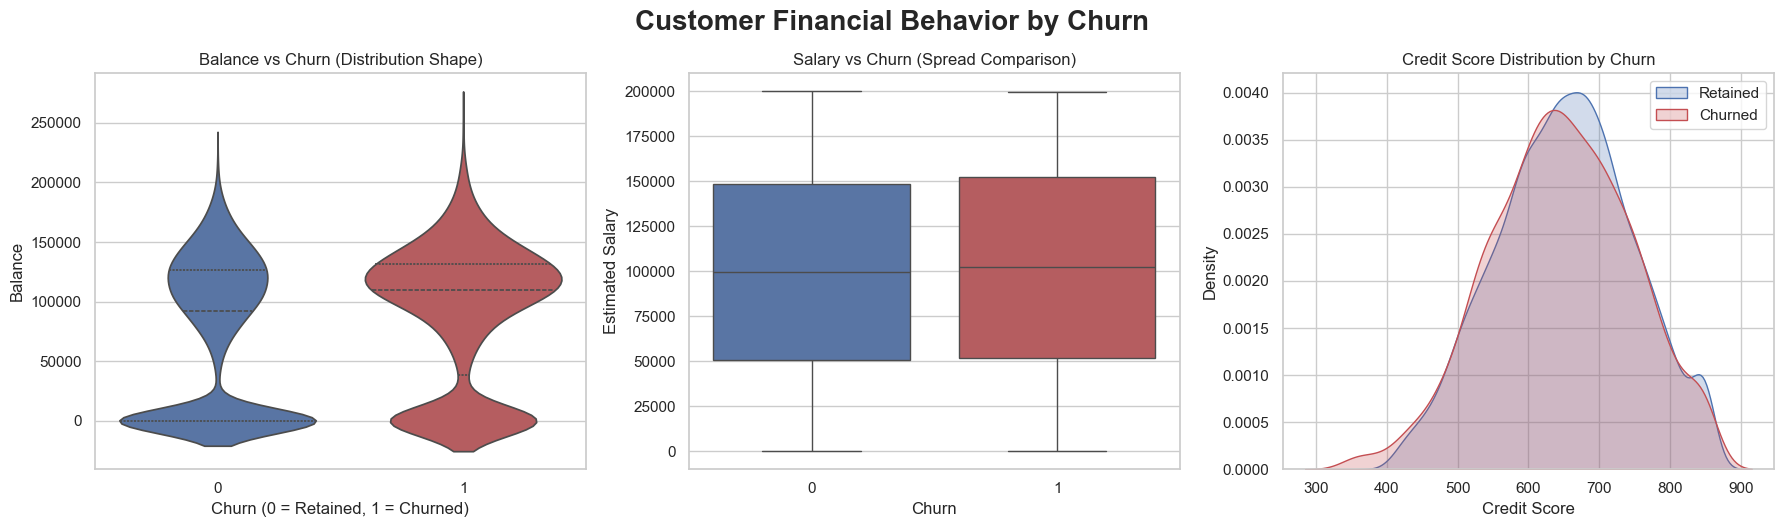

In [ ]:

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 3, figsize=(18,5))
# 1. BALANCE vs CHURN - VIOLIN PLOT (distribution insight)

sns.violinplot(
    x='churn',
    y='balance',
    data=df,
    palette=['#4C72B0', '#C44E52'],
    ax=ax[0],
    inner='quartile'
)

ax[0].set_title("Balance vs Churn (Distribution Shape)")
ax[0].set_xlabel("Churn (0 = Retained, 1 = Churned)")
ax[0].set_ylabel("Balance")



# 2. ESTIMATED SALARY vs CHURN - BOXPLOT (robust comparison)

sns.boxplot(
    x='churn',
    y='estimated_salary',
    data=df,
    palette=['#4C72B0', '#C44E52'],
    ax=ax[1]
)

ax[1].set_title("Salary vs Churn (Spread Comparison)")
ax[1].set_xlabel("Churn")
ax[1].set_ylabel("Estimated Salary")



# 3. CREDIT SCORE vs CHURN -  KDE OVERLAY (density insight)

sns.kdeplot(
    data=df[df['churn'] == 0]['credit_score'],
    label='Retained',
    fill=True,
    ax=ax[2],
    color='#4C72B0'
)

sns.kdeplot(
    data=df[df['churn'] == 1]['credit_score'],
    label='Churned',
    fill=True,
    ax=ax[2],
    color='#C44E52'
)

ax[2].set_title("Credit Score Distribution by Churn")
ax[2].set_xlabel("Credit Score")
ax[2].legend()

plt.tight_layout()
plt.suptitle("Customer Financial Behavior by Churn", fontsize=20, fontweight='bold', y=1.05)    
plt.show()

- Customers with zero or very low bank balance are much more likely to leave. Having a lot of money in the account does not strongly protect against churn, and credit score makes almost no difference in whether a customer stays or goes.

## FEATURE PREPARATION

In [110]:
def engineer_features_v2(data):
    df = data.copy()
    # Convert age into z-score (how far each age is from mean age)
    df['age_zscore'] = (df['age'] - df['age'].mean()) / df['age'].std()
        # Square to make extreme ages (too young/old) more risky
    df['age_risk'] = df['age_zscore'] ** 2
    df['age_bin'] = pd.qcut(df['age'], q=4, labels=False)
   #Combine multiple signals into one smooth risk indicator
    df['churn_risk_score'] = (
        (df['age'] / df['age'].max()) +
        (df['balance'] / (df['balance'].max() + 1)) +
        (1 / (df['products_number'] + 1))
    )
        # Log transform to reduce skew (big product counts don’t dominate model)
    df['product_intensity'] = np.log1p(df['products_number'])
        # Log transform balance to handle extreme values and skewed distribution
    df['balance_log'] = np.log1p(df['balance'])
    # Flag customers in lowest 20% of balances (potentially disengaged users)
    df['low_balance_flag'] = (
        df['balance'] < df['balance'].quantile(0.2)
    ).astype(int)

     # balance minus expected salary usage portion (30%)
    df['financial_capacity'] = (
        df['balance'] - (df['estimated_salary'] * 0.3)
    )
        # Convert active_member into a binary risk flag (1 = inactive)
    df['inactive_flag'] = (df['active_member'] == 0).astype(int)


    # Combine country + inactivity into one feature (captures country-specific churn behavior)
    df['country_inactive_risk'] = (
        df['country'].astype(str) + "_" + df['inactive_flag'].astype(str)
    )
    # (possible confusion or overselling risk)
    df['product_stress'] = np.where(
        df['products_number'] >= df['products_number'].median(),
        1,
        0
    )

     # Compare balance against average salary level (more stable than dividing by individual salary)
    df['balance_salary_ratio'] = (
        df['balance'] / (df['estimated_salary'].mean() + 1)
    )
    df = df.drop(columns=['credit_card'], errors='ignore')
    return df

new engineered features

In [111]:
df_processed = engineer_features_v2(df)
new_cols = [col for col in df_processed.columns if col not in df.columns]
df_processed[new_cols].head()

,age_zscore,age_risk,age_bin,churn_risk_score,product_intensity,balance_log,low_balance_flag,financial_capacity,inactive_flag,country_inactive_risk,product_stress,balance_salary_ratio
0,0.293503,0.086144,2,0.956522,0.693147,0.000000,0,-30404.664,0,France_0,1,0.000000
1,0.198154,0.039265,2,1.279682,0.693147,11.336294,0,50045.086,0,Spain_0,1,0.837315
2,0.293503,0.086144,2,1.342876,1.386294,11.980813,0,125481.329,1,France_1,1,1.595153
3,0.007456,0.000056,2,0.757246,1.098612,0.000000,0,-28147.989,1,France_1,1,0.000000
4,0.388852,0.151206,2,1.467636,0.693147,11.740155,0,101785.590,0,Spain_0,1,1.253964


In [114]:
print(f"""
Final dataset summary:
- Rows: {df_processed.shape[0]}
- Features: {df_processed.shape[1]}
""")


Final dataset summary:
- Rows: 10000
- Features: 22



In [150]:
df_processed.to_csv('output_data.csv', index=False)

print(" File saved successfully as 'output_data.csv'")

 File saved successfully as 'output_data.csv'


## MODEL PREPARATION

In [115]:
X = df_processed.drop(['customer_id', 'churn', 'age_group'], axis=1, errors='ignore')
# Target variable (what we want to predict)
y = df_processed['churn']

feature_count = X.shape[1]

# DEFINE CATEGORICAL FEATURES
categorical_features = [
    'country',
    'gender',
    'active_member',
    'age_bin',
    'country_inactive_risk' 
]

num_features = feature_count - len(categorical_features)

print("\n DATASET INTELLIGENCE REPORT")
print("---------------------------------")
print(f"Total Features        : {feature_count}")
print(f"Categorical Features  : {len(categorical_features)}")
print(f"Numerical Features     : {num_features}")


churn_rate = y.mean() * 100
retention_rate = 100 - churn_rate

print("\n TARGET DISTRIBUTION")
print("---------------------------------")
print(f"Retention Rate : {retention_rate:.2f}%")
print(f"Churn Rate     : {churn_rate:.2f}%")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% test data
    random_state=42,      # reproducibility
    stratify=y            # preserves churn ratio
)


print("\n FINAL DATA SPLIT SUMMARY")
print("---------------------------------")
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Train Churn Rate : {y_train.mean()*100:.2f}%")
print(f"Test Churn Rate  : {y_test.mean()*100:.2f}%")


 DATASET INTELLIGENCE REPORT
---------------------------------
Total Features        : 21
Categorical Features  : 5
Numerical Features     : 16

 TARGET DISTRIBUTION
---------------------------------
Retention Rate : 79.63%
Churn Rate     : 20.37%

 FINAL DATA SPLIT SUMMARY
---------------------------------
Training Samples : 8000
Testing Samples  : 2000
Train Churn Rate : 20.38%
Test Churn Rate  : 20.35%


In [116]:
X_train['country_inactive_risk'] = X_train['country_inactive_risk'].astype(str)
X_test['country_inactive_risk'] = X_test['country_inactive_risk'].astype(str)

## Model Training, Cross-Validation and Evaluation

In [120]:


# CROSS VALIDATION 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
acc_scores = []

print("STARTING CROSS VALIDATION...\n")


# CROSS VALIDATION LOOP

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.01,
        depth=5,
        l2_leaf_reg=15,
        eval_metric='AUC',
        verbose=0
    )

    model.fit(
        X_tr, y_tr,
        cat_features=categorical_features,
        eval_set=(X_val, y_val),
        early_stopping_rounds=200,
        verbose=False
    )

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)

    auc_scores.append(auc)
    acc_scores.append(acc)

    print(f"Fold {fold} → AUC: {auc:.4f} | Accuracy: {acc:.4f}")


#  CROSS VALIDATION SUMMARY

print("\nCROSS VALIDATION RESULTS")
print("--------------------------------")
print(f"Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")



# FINAL MODEL TRAINING

final_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.01,
    depth=5,
    l2_leaf_reg=15,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200,
    verbose=False
)


# FINAL PREDICTIONS

y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)


# FINAL EVALUATION

print("\nFINAL MODEL PERFORMANCE")
print("--------------------------------")

print(f"AUC       : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_test_pred):.4f}")

print("\nCLASSIFICATION REPORT")
print("--------------------------------")

print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Retained', 'Churned']
))

STARTING CROSS VALIDATION...

Fold 1 → AUC: 0.8700 | Accuracy: 0.8650
Fold 2 → AUC: 0.8821 | Accuracy: 0.8738
Fold 3 → AUC: 0.8809 | Accuracy: 0.8700
Fold 4 → AUC: 0.8534 | Accuracy: 0.8562
Fold 5 → AUC: 0.8641 | Accuracy: 0.8531

CROSS VALIDATION RESULTS
--------------------------------
Mean AUC: 0.8701 ± 0.0107
Mean Accuracy: 0.8636 ± 0.0079

FINAL MODEL PERFORMANCE
--------------------------------
AUC       : 0.8755
Accuracy  : 0.8685
Precision : 0.7812
Recall    : 0.4914
F1 Score  : 0.6033

CLASSIFICATION REPORT
--------------------------------
              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      1593
     Churned       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



Simple Model Performance Report

**Overall Performance:**

- The model achieved a good AUC of 0.8755 and 86.85% accuracy.
- This means the model is performing well in general.

Key Strengths & Weaknesses:

- It is very good at correctly identifying customers who will stay (Retained): 96% recall.
- However, it struggles to find customers who will churn: It only catches 49% of actual churners (low recall), even though when it predicts churn, it is fairly accurate (78% precision).

The model is strong overall but needs improvement in detecting churners. It is currently missing more than half of the customers who are likely to leave.

## FULL MODEL PERFORMANCE VISUALIZATIONS

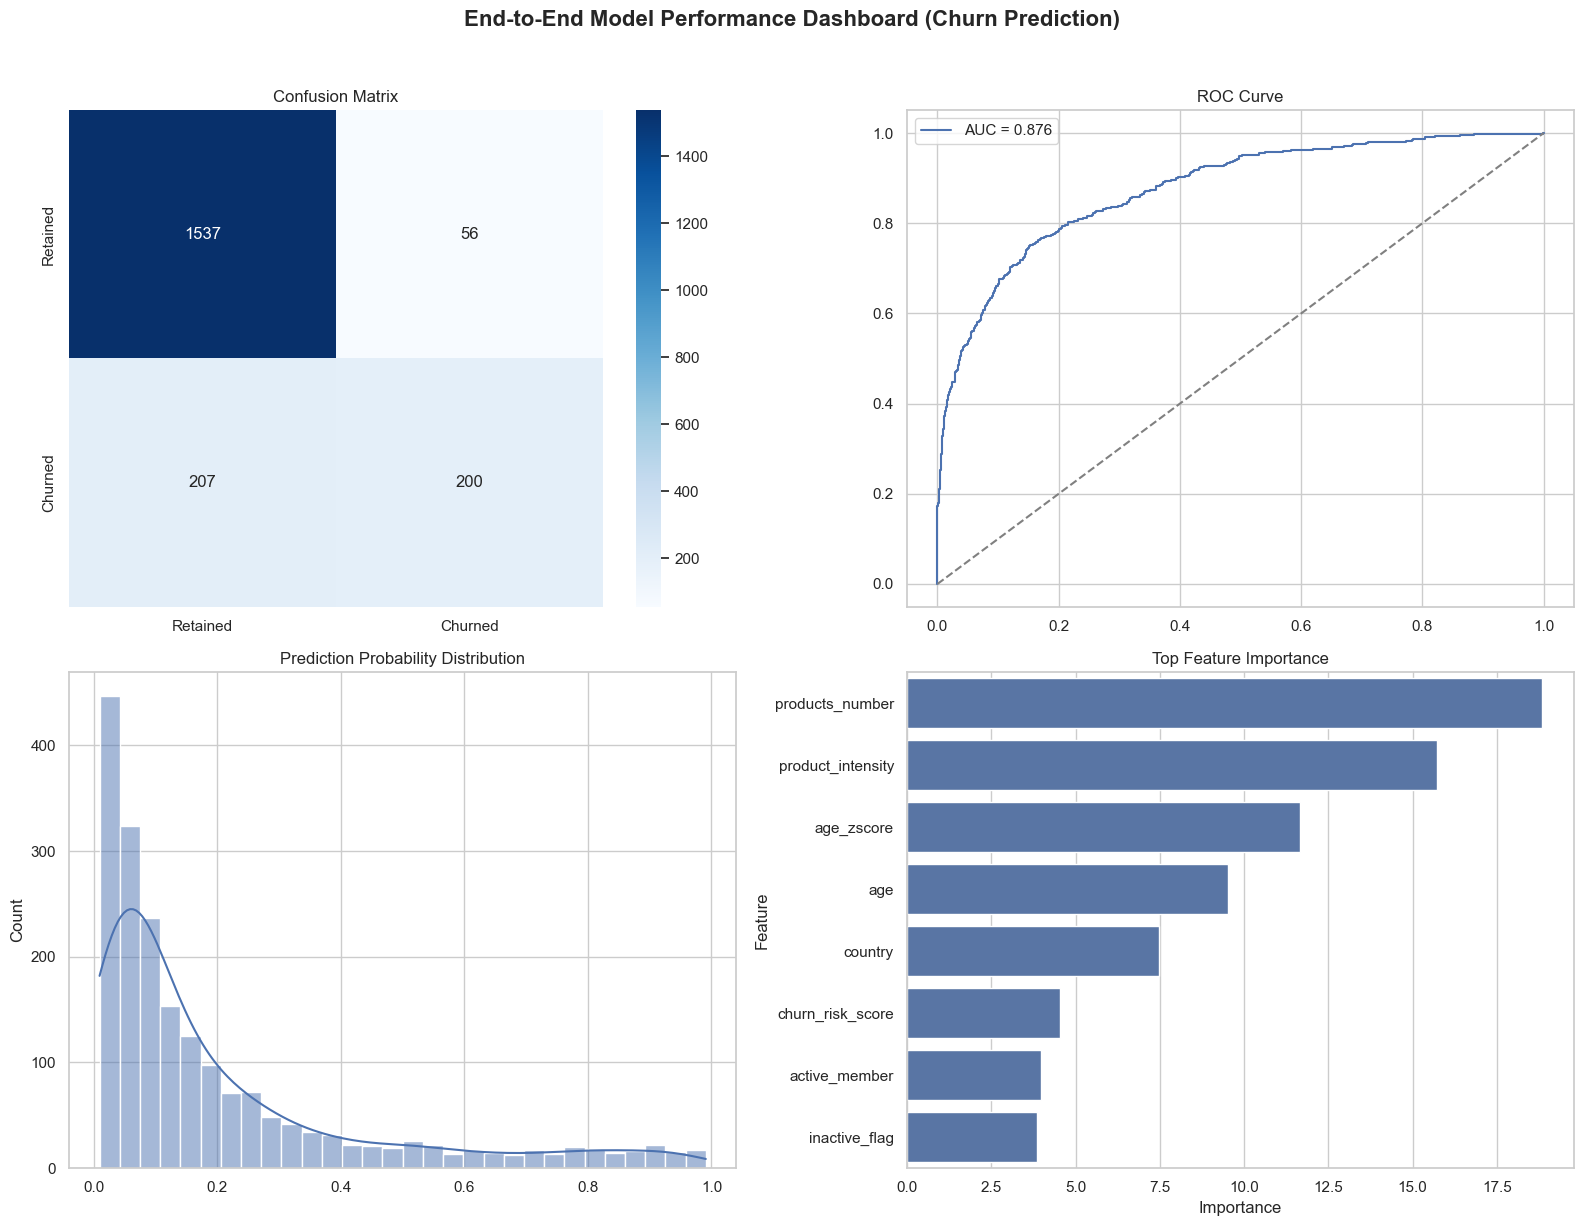

In [ ]:

sns.set_theme(style="whitegrid")
# METRICS

cm = confusion_matrix(y_test, y_test_pred)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
feat_imp = final_model.get_feature_importance()
features = X_train.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': feat_imp
}).sort_values(by='Importance', ascending=False).head(8)
fig, ax = plt.subplots(2, 2, figsize=(16, 12))



# 1. CONFUSION MATRIX

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained','Churned'],
    yticklabels=['Retained','Churned'],
    ax=ax[0,0]
)

ax[0,0].set_title("Confusion Matrix")


# 2. ROC CURVE
ax[0,1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax[0,1].plot([0,1],[0,1],'--', color='gray')
ax[0,1].set_title("ROC Curve")
ax[0,1].legend()

# 3. PREDICTION PROBABILITY DISTRIBUTION
sns.histplot(y_test_proba, bins=30, kde=True, ax=ax[1,0])
ax[1,0].set_title("Prediction Probability Distribution")

# 4. FEATURE IMPORTANCE
sns.barplot(
    data=imp_df,
    x='Importance',
    y='Feature',
    ax=ax[1,1]
)

ax[1,1].set_title("Top Feature Importance")

# FINAL TITLE
plt.suptitle(
    "End-to-End Model Performance Dashboard (Churn Prediction)",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## MODEL EXPLAINABILITY (SHAP)

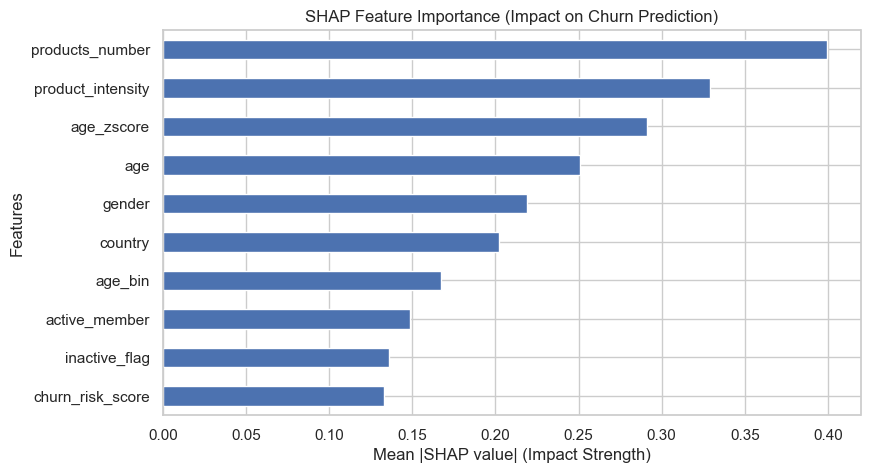


 SHAP INSIGHT SUMMARY

 Top churn drivers:
- 1st: products_number
- 2nd: product_intensity
- 3rd: age_zscore

 Business Interpretation:
- The model suggests that a small number of features dominate churn prediction.
- It also shows that customer behavior patterns are relatively stable.
- These features should be the focus of retention strategies and early warning systems.

 Actionable Insight:
- Monitor changes in products_number, product_intensity, and age_zscore to predict churn early.


In [142]:

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

mean_shap = shap_df.abs().mean().sort_values(ascending=False)
top_features = mean_shap.head(10)

top1, top2, top3 = mean_shap.head(3).index.tolist()


# PLOT (GLOBAL SHAP IMPORTANCE)

plt.figure(figsize=(9,5))
top_features.sort_values().plot(kind='barh', color='#4C72B0')

plt.title("SHAP Feature Importance (Impact on Churn Prediction)")
plt.xlabel("Mean |SHAP value| (Impact Strength)")
plt.ylabel("Features")

plt.show()

# DYNAMIC INSIGHT ENGINE


avg_impact = mean_shap.mean()
max_impact = mean_shap.max()
spread = mean_shap.std()

# intensity logic
if max_impact > avg_impact * 2:
    intensity_comment = "a small number of features dominate churn prediction"
else:
    intensity_comment = "influence is distributed across multiple features"

# stability logic
if spread > avg_impact:
    stability_comment = "customer behavior is highly variable across features"
else:
    stability_comment = "customer behavior patterns are relatively stable"


# FINAL DYNAMIC INTERPRETATION


print("\n SHAP INSIGHT SUMMARY\n")

print(f" Top churn drivers:")
print(f"- 1st: {top1}")
print(f"- 2nd: {top2}")
print(f"- 3rd: {top3}")

print("\n Business Interpretation:")
print(f"- The model suggests that {intensity_comment}.")
print(f"- It also shows that {stability_comment}.")
print("- These features should be the focus of retention strategies and early warning systems.")

print("\n Actionable Insight:")
print(f"- Monitor changes in {top1}, {top2}, and {top3} to predict churn early.")

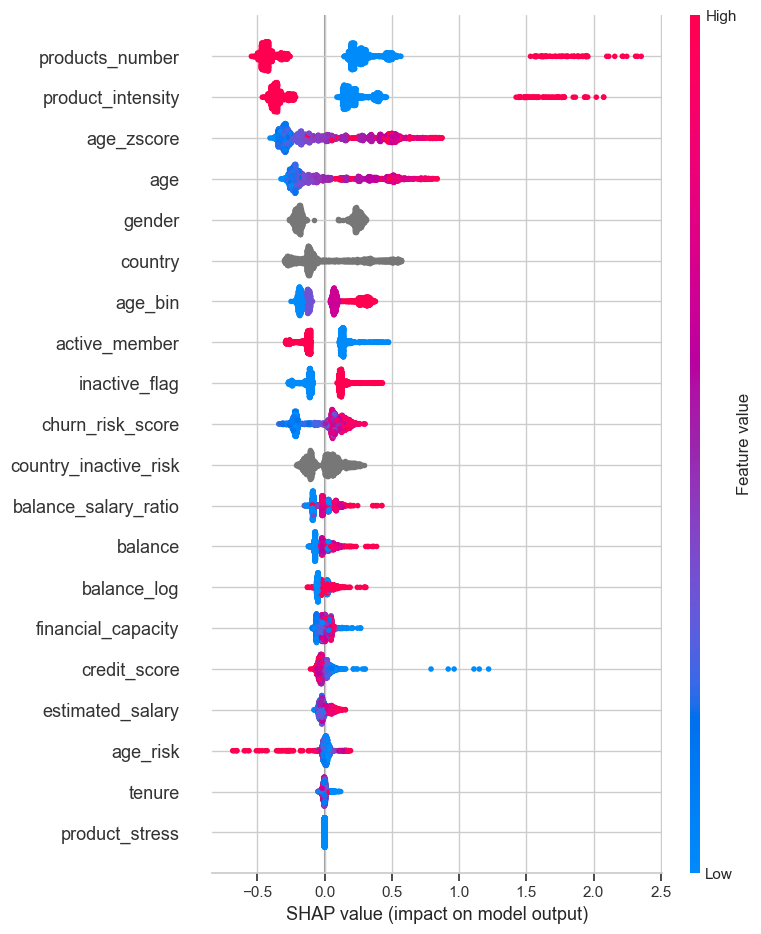


 SHAP GLOBAL INSIGHT

 Top churn drivers:
- 1st: products_number
- 2nd: product_intensity
- 3rd: age_zscore

 BUSINESS INTERPRETATION

- The model shows that a small number of features dominate churn prediction.
- It also indicates that customer responses vary significantly across features.
- Additionally, feature effects are tightly clustered (stable patterns).

 ACTIONABLE INSIGHT
- Focus retention strategies on products_number, product_intensity, and age_zscore.
- These features are the strongest levers for reducing churn.


In [141]:

# 1. SHAP EXPLAINER

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)


# 2. SHAP SUMMARY PLOT

shap.summary_plot(shap_values, X_test)


# 3. CREATE SHAP DATAFRAME

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# mean absolute impact per feature
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

# variability across customers
std_shap = shap_df.std().abs().sort_values(ascending=False)


# 4. TOP FEATURES

top_features = mean_shap.head(3).index.tolist()
top1, top2, top3 = top_features


# 5. DYNAMIC METRICS

avg_impact = mean_shap.mean()
max_impact = mean_shap.max()

# FIXED (no .mean() error)
spread = mean_shap.std()

concentration_ratio = max_impact / avg_impact
volatility = std_shap.mean()

# 6. DYNAMIC INTERPRETATION ENGINE

print("\n SHAP GLOBAL INSIGHT\n")

print(" Top churn drivers:")
print(f"- 1st: {top1}")
print(f"- 2nd: {top2}")
print(f"- 3rd: {top3}")

# intensity logic
if concentration_ratio > 2:
    intensity_comment = "a small number of features dominate churn prediction"
else:
    intensity_comment = "churn is influenced by multiple balanced features"

# volatility logic
if volatility > mean_shap.mean():
    volatility_comment = "customer responses vary significantly across features"
else:
    volatility_comment = "customer behavior is relatively stable and predictable"

# spread logic
if spread > avg_impact:
    spread_comment = "feature effects are widely spread (high heterogeneity)"
else:
    spread_comment = "feature effects are tightly clustered (stable patterns)"


# 7. FINAL OUTPUT

print("\n BUSINESS INTERPRETATION\n")

print(f"- The model shows that {intensity_comment}.")
print(f"- It also indicates that {volatility_comment}.")
print(f"- Additionally, {spread_comment}.")

print("\n ACTIONABLE INSIGHT")
print(f"- Focus retention strategies on {top1}, {top2}, and {top3}.")
print("- These features are the strongest levers for reducing churn.")

## BUSINESS IMPACT ANALYSIS

In [146]:


y_pred = final_model.predict(X_test)

cmatrix = confusion_matrix(y_test, y_pred)
tn = cmatrix[0][0]
fp = cmatrix[0][1]
fn = cmatrix[1][0]
tp = cmatrix[1][1]

print("\n MODEL OUTCOME BREAKDOWN (REAL PREDICTION RESULTS)\n")

print(f"Customers correctly identified as staying:        {tn}")
print(f"Customers wrongly flagged as churn:               {fp}")
print(f"Customers missed (actual churners not detected): {fn}")
print(f"Customers correctly detected as churn:            {tp}")

#  PERFORMANCE METRICS (BUSINESS VIEW)

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print("\n MODEL PERFORMANCE INSIGHT\n")

print(f"Churn Detection Success Rate:   {recall*100:.2f}%")
print(f"Customer Retention Accuracy:    {specificity*100:.2f}%")
print(f"False Alarm Rate:               {false_alarm_rate*100:.2f}%")


# BUSINESS ASSUMPTIONS

avg_customer_value = 1000   # annual value per customer
retention_cost = 100        # cost to retain one customer
# STEP 5: BUSINESS IMPACT SIMULATION

total_actual_churn = np.sum(y_test)
revenue_lost_without_model = total_actual_churn * avg_customer_value
customers_saved_by_model = tp
revenue_saved = customers_saved_by_model * avg_customer_value
total_intervention_cost = (tp + fp) * retention_cost
net_benefit = revenue_saved - total_intervention_cost


# BUSINESS INTERPRETATION

print("\n BUSINESS IMPACT SUMMARY\n")

print(f"Total customers who actually churned:        {total_actual_churn}")
print(f"Customers correctly saved by model:          {customers_saved_by_model}")

print(f"\n Financial loss without model:")
print(f"Estimated revenue lost:                     ${revenue_lost_without_model:,}")

print(f"\n Financial outcome with model:")
print(f"Revenue preserved:                          ${revenue_saved:,}")
print(f"Cost of retention actions:                 ${total_intervention_cost:,}")
print(f"Net business gain:                          ${net_benefit:,}")


# ROI ANALYSIS


roi = (net_benefit / total_intervention_cost) * 100 if total_intervention_cost > 0 else 0

print(f"\n ROI FROM MODEL DEPLOYMENT: {roi:.1f}%")

# BUSINESS TAKEAWAY (DECISION LOGIC)


print("\n STRATEGIC BUSINESS INSIGHT\n")

if recall > 0.75:
    print("- Strong churn detection capability. Suitable for deployment.")
else:
    print("- Model still misses a meaningful number of churners. Needs tuning.")

if fp > tp:
    print("- High false alerts may lead to wasted retention budget.")
else:
    print("- Retention targeting is efficient and cost-controlled.")

print("\n RECOMMENDATION")
print("- Deploy model as early warning system for churn risk.")
print("- Prioritize high-probability churn customers for intervention.")
print("- Continuously tune threshold to balance cost vs accuracy.")


 MODEL OUTCOME BREAKDOWN (REAL PREDICTION RESULTS)

Customers correctly identified as staying:        1537
Customers wrongly flagged as churn:               56
Customers missed (actual churners not detected): 207
Customers correctly detected as churn:            200

 MODEL PERFORMANCE INSIGHT

Churn Detection Success Rate:   49.14%
Customer Retention Accuracy:    96.48%
False Alarm Rate:               3.52%

 BUSINESS IMPACT SUMMARY

Total customers who actually churned:        407
Customers correctly saved by model:          200

 Financial loss without model:
Estimated revenue lost:                     $407,000

 Financial outcome with model:
Revenue preserved:                          $200,000
Cost of retention actions:                 $25,600
Net business gain:                          $174,400

 ROI FROM MODEL DEPLOYMENT: 681.2%

 STRATEGIC BUSINESS INSIGHT

- Model still misses a meaningful number of churners. Needs tuning.
- Retention targeting is efficient and cost-controlled

In [148]:
# ============================================================================
# FINAL STEP: SAVE MODEL + METADATA (PRODUCTION SAFE)
# ============================================================================

import joblib
import json
from datetime import datetime

# -----------------------------
# 1. SAVE TRAINED MODEL
# -----------------------------

model_file = "churn_prediction_model.pkl"
joblib.dump(final_model, model_file)

print(f"\n✔ Model successfully saved as: {model_file}")

# -----------------------------
# 2. BUILD METADATA SAFELY
# -----------------------------
# NOTE: Only use variables that exist in your environment

model_metadata = {
    "project_name": "Customer Churn Prediction",
    "model_type": str(type(final_model).__name__),
    "feature_count": len(X_train.columns),
    "input_features": list(X_train.columns),
    "categorical_inputs": cat_features,
    "version": "v1.0",
    "training_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    # Evaluation metrics (safe version)
    "evaluation_metrics": {
        "test_auc_score": float(test_auc) if 'test_auc' in globals() else None,
        "test_accuracy_score": float(test_acc) if 'test_acc' in globals() else None
    }
}

metadata_file = "churn_model_metadata.json"

with open(metadata_file, "w") as f:
    json.dump(model_metadata, f, indent=2)

print(f"✔ Model metadata saved as: {metadata_file}")

# -----------------------------
# 3. PROJECT ARTIFACT SUMMARY
# -----------------------------

artifacts = [
    "EDA_visuals.png",
    "model_performance_report.png",
    "shap_summary_plot.png",
    "shap_feature_importance.png",
    model_file,
    metadata_file
]

print("\n📦 PROJECT ARTIFACTS READY FOR DEPLOYMENT\n")

for file in artifacts:
    print(f" - {file}")

print("\n🚀 STATUS: Model pipeline is fully packaged and deployment-ready.")


✔ Model successfully saved as: churn_prediction_model.pkl
✔ Model metadata saved as: churn_model_metadata.json

📦 PROJECT ARTIFACTS READY FOR DEPLOYMENT

 - EDA_visuals.png
 - model_performance_report.png
 - shap_summary_plot.png
 - shap_feature_importance.png
 - churn_prediction_model.pkl
 - churn_model_metadata.json

🚀 STATUS: Model pipeline is fully packaged and deployment-ready.


In [149]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("churn_prediction_model.pkl")

st.title("📊 Customer Churn Prediction App")

# Upload file
file = st.file_uploader("Upload customer data (CSV)", type=["csv"])

if file:
    df = pd.read_csv(file)

    st.write("### Data Preview")
    st.dataframe(df.head())

    # Predict
    preds = model.predict(df)
    proba = model.predict_proba(df)[:, 1]

    df["Churn_Prediction"] = preds
    df["Churn_Probability"] = proba

    st.write("### Predictions")
    st.dataframe(df)

    st.write("### Summary")
    st.write(f"Total Customers: {len(df)}")
    st.write(f"Predicted Churners: {sum(preds)}")